# Random Forest Classifier

**Dataset:** Credit Score Classification

This notebook follows the standard bake-off methodology[cite: 2]:

1. Dataset Loading & Preview
2. Preprocessing Pipeline (Maximizing Features)
3. Hyperparameter Tuning Log
4. Final Model Selection Leaderboard
5. Best Model Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

## 1. Dataset Loading & Preview

Load the dataset and inspect initial statistics, referencing the verbatim data source[cite: 1].

In [2]:
df = pd.read_csv("test.csv")
print(f"Dataset shape: {df.shape}")
display(df.head())
print("\nColumn Information:")
df.info()

Dataset shape: (50000, 27)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null

## 2. Preprocessing Pipeline

Structured preprocessing based on the provided methodology[cite: 1]:

### 1. Data Cleaning (Noise Removal)
- Strip noise characters (`_`, `-`) and convert to numeric[cite: 1].
- Convert `Credit_History_Age` to total months[cite: 1].

### 2. Handling Missing Values
- **Numeric:** Fill with median[cite: 1].
- **Categorical:** Fill with mode and handle placeholders like `_______`[cite: 1].

### 3. Feature Engineering (MAXIMIZING FEATURES)
- Expand `Type_of_Loan` into binary dummy variables to ensure every unique loan type provides a predictive feature.

In [3]:
TARGET = "Credit_Mix"

# 1. Noise Removal[cite: 1]
numeric_fix_cols = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']
for col in numeric_fix_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('_', '').str.replace('-', ''), errors='coerce')

def convert_credit_age(val):
    if pd.isna(val) or not isinstance(val, str): return np.nan
    try:
        parts = val.split()
        return int(parts[0]) * 12 + int(parts[3])
    except: return np.nan
if 'Credit_History_Age' in df.columns:
    df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_credit_age)

# 2. Imputation[cite: 1]
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df['Occupation'] = df['Occupation'].replace('_______', np.nan)
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Feature Expansion
loan_dummies = df['Type_of_Loan'].str.get_dummies(sep=', ')
df_expanded = pd.concat([df, loan_dummies], axis=1)

# 4. Final Encoding & Selection[cite: 1]
le = LabelEncoder()
for col in cat_cols:
    df_expanded[col] = le.fit_transform(df_expanded[col].astype(str))

drop_cols = ['ID', 'Customer_ID', 'SSN', 'Name', 'Month', 'Type_of_Loan']
X = df_expanded.drop(columns=[c for c in drop_cols if c in df_expanded.columns] + [TARGET])
y = df_expanded[TARGET]

scaler = StandardScaler()
X[['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt']] = scaler.fit_transform(X[['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Preprocessing Complete.")
print(f"Total Features used: {X.shape[1]}")

Preprocessing Complete.
Total Features used: 38


## 3. Hyperparameter Tuning Log

Iterating through configurations to optimize the Random Forest model[cite: 2].

In [4]:
experiments = [
    {"Exp ID": "RF_01", "n_estimators": 100, "max_depth": 10},
    {"Exp ID": "RF_02", "n_estimators": 200, "max_depth": 20},
    {"Exp ID": "RF_03", "n_estimators": 300, "max_depth": None}
]

results = []
for exp in experiments:
    clf = RandomForestClassifier(n_estimators=exp['n_estimators'], max_depth=exp['max_depth'], random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    exp['Validation Accuracy'] = round(acc, 4)
    results.append(exp)

results_df = pd.DataFrame(results)
display(results_df)

,Exp ID,n_estimators,max_depth,Validation Accuracy
0,RF_01,100,10.0,0.7580
1,RF_02,200,20.0,0.7765
2,RF_03,300,NaN,0.7743


## 4. Final Model Selection Leaderboard

Ranking models based on accuracy[cite: 2].

In [9]:
# Create the leaderboard and ensure parameters are cast correctly to avoid float errors
leaderboard = results_df.sort_values("Validation Accuracy", ascending=False).reset_index(drop=True)
leaderboard['Rank'] = leaderboard.index + 1

# Convert n_estimators back to integer to prevent Scikit-Learn validation errors
leaderboard['n_estimators'] = leaderboard['n_estimators'].astype(int)

display(leaderboard[['Rank', 'Exp ID', 'Validation Accuracy']])

,Rank,Exp ID,Validation Accuracy
0,1,RF_02,0.7765
1,2,RF_03,0.7743
2,3,RF_01,0.7580


## 5. Best Model Analysis

Detailed performance of the top-performing Random Forest model[cite: 2].


Best Model: RF_02
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1911
           1       0.78      0.97      0.86      2452
           2       0.78      0.95      0.86      3676
           3       0.19      0.01      0.02      1961

    accuracy                           0.78     10000
   macro avg       0.64      0.73      0.65     10000
weighted avg       0.67      0.78      0.70     10000



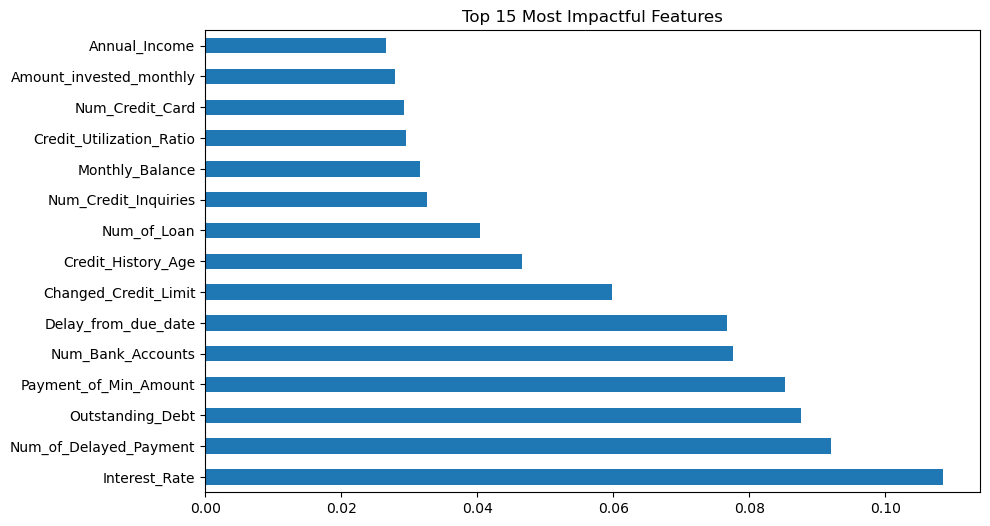

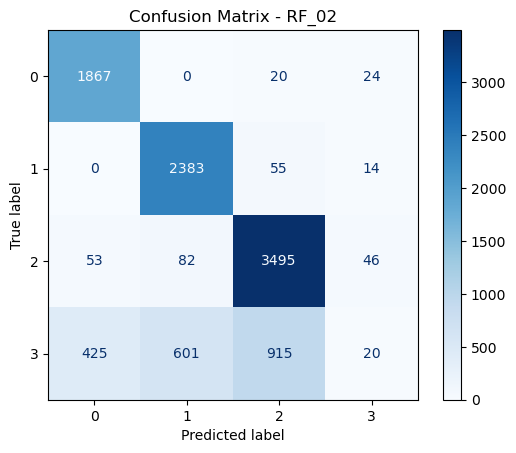

In [10]:
# Retrieve the best row from the leaderboard
best_row = leaderboard.iloc[0]
best_id = best_row['Exp ID']
print(f"\nBest Model: {best_id}")

# Extract parameters and handle the type conversion explicitly
best_n = int(best_row['n_estimators'])
# Use np.nan check because 'None' becomes NaN in float-convertible DataFrames
best_depth = None if pd.isna(best_row['max_depth']) else int(best_row['max_depth'])

# Re-initialize the classifier with verified integer types
clf = RandomForestClassifier(
    n_estimators=best_n, 
    max_depth=best_depth, 
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualization of feature importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
# Random Forest allows us to maximize features and see which perform best[cite: 1]
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Top 15 Most Impactful Features")
plt.show()

# Confusion Matrix[cite: 2]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - {best_id}")
plt.show()